<a href="https://colab.research.google.com/github/Car27VeP/Data_Science_Projects/blob/main/Fraud%26Risk_In_Malta_iGaming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🕵️‍♂️ Tu Misión de Analista (20-25 min):
Alerta de Lavado: Crea un filtro para encontrar jugadores que tengan sessions_count == 1 y que su total_deposits sea igual a su total_wagered.

Pregunta: ¿Qué ID de jugador te arroja?

Alerta de Bot: Crea una columna llamada engagement_ratio que sea total_wagered / sessions_count. Filtra a los jugadores que tengan un ratio menor a 0.5 pero que tengan más de 100 sesiones.

Insight: Estos son perfiles que entran mucho a la página pero no generan valor; podrían estar haciendo "scraping" de datos.

Segmentación de Riesgo: Crea una nueva columna llamada risk_level.

Si total_wagered es mayor a 3500, ponle "High".

Si no, ponle "Normal".

Tip: Puedes usar np.where(df['total_wagered'] > 3500, 'High', 'Normal').

Visualización de Alerta: Haz un gráfico de barras que cuente cuántos jugadores hay en cada risk_level.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Generamos la base de ayer
np.random.seed(42)
data = {
    'player_id': range(101, 201),
    'total_deposits': np.random.normal(500, 200, 100).round(2),
    'total_wagered': np.random.normal(2000, 800, 100).round(2),
    'sessions_count': np.random.randint(1, 50, 100),
    'country': np.random.choice(['Mexico', 'Spain', 'Malta', 'Italy', 'UK'], 100)
}
df = pd.DataFrame(data)

# --- INYECTAMOS ANOMALÍAS (Los sospechosos) ---
# Caso 1: El "Lavador de dinero" (Mucho depósito, apuesta exacta, 1 sola sesión)
df.loc[0] = [999, 5000.00, 5000.00, 1, 'Malta']

# Caso 2: El "Bot" (Muchísimas sesiones, pero no apuesta casi nada)
df.loc[1] = [888, 10.00, 2.00, 500, 'Italy']

In [ ]:
df.head()

,player_id,total_deposits,total_wagered,sessions_count,country
0,999,5000.00,5000.00,1,Malta
1,888,10.00,2.00,500,Italy
2,103,629.54,1725.83,17,Italy
3,104,804.61,1358.18,40,Spain
4,105,453.17,1870.97,33,Spain


In [ ]:
# Alerta de lavado.
laundry_alerts = df[(df['sessions_count'] == 1) & (df['total_deposits'] == df['total_wagered'])]
laundry_alerts
# El jugador 999 puede estar causando fraude con lavado de dinero.

,player_id,total_deposits,total_wagered,sessions_count,country
0,999,5000.0,5000.0,1,Malta


In [ ]:
# Alerta de Bot
df['engagement_ratio'] = df['total_wagered']/df['sessions_count']
bots_alerts = df[(df['engagement_ratio'] < 0.5) & (df['sessions_count'] > 100)]
bots_alerts
# El judagador 888 puede ser un posible bot.

,player_id,total_deposits,total_wagered,sessions_count,country,engagement_ratio
1,888,10.0,2.0,500,Italy,0.004


<Axes: title={'center': 'Segmatación de riesgo.'}, xlabel='risk_level'>

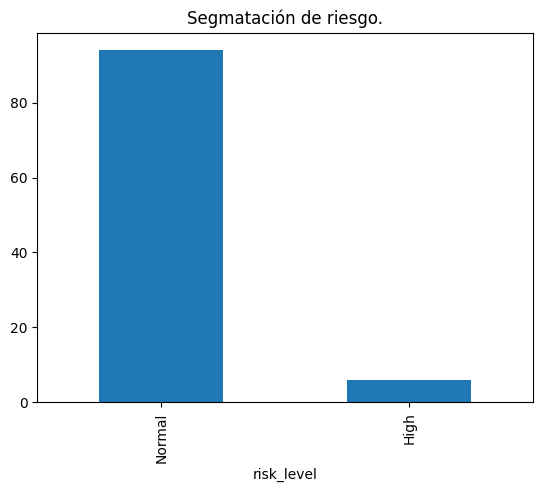

In [ ]:
# Segmentacion de riesgo
df['risk_level'] = np.where(df['total_wagered'] > 3500,'High','Normal')
df['risk_level'].value_counts().plot(kind='bar',title='Segmatación de riesgo.')
#Los usuarios normales abarcan mas del 90% del grupo de segmentacion de riesgo.

# Reporte Ejecutivo
Tu código debe hacer lo siguiente:

Formateo de Dinero: Crea una función que convierta los números en formato de moneda (Ej: de 5000 a $5,000.00).

Tip: Puedes usar f-strings: f"${valor:,.2f}".

Resumen de Hallazgos: Crea un pequeño "print" final que diga:

"Total de transacciones analizadas: [X]"

"Alertas de lavado de dinero encontradas: [X]"

"Posibles Bots detectados: [X]"

Visualización de "Impacto Económico": Haz una gráfica de pastel (pie chart) que muestre cuánto dinero representan las apuestas del grupo de "Riesgo High" frente al grupo "Normal".

Esto es vital porque a los jefes les importa saber: "¿Qué tanto dinero estamos arriesgando?".

In [ ]:
def num_to_currency(num):
  return f"${num:,.2f}"

In [ ]:
df['total_deposits_currency'] = df['total_deposits'].apply(num_to_currency)
df['total_wagered_currency'] = df['total_wagered'].apply(num_to_currency)

In [ ]:
print(f"Total de transacciones analizadas: {len(df)}")
print(f"Alertas de lavado de dinero encontradas: {len(laundry_alerts)}")
print(f"Posibles bots detectados: {len(bots_alerts)}")

Total de transacciones analizadas: 100
Alertas de lavado de dinero encontradas: 1
Posibles bots detectados: 1


In [ ]:
impacto_economico = df.groupby('risk_level')['total_wagered'].sum()
labels= impacto_economico.index

print(impacto_economico)
print(labels)

risk_level
High       23925.47
Normal    180329.69
Name: total_wagered, dtype: float64
Index(['High', 'Normal'], dtype='object', name='risk_level')


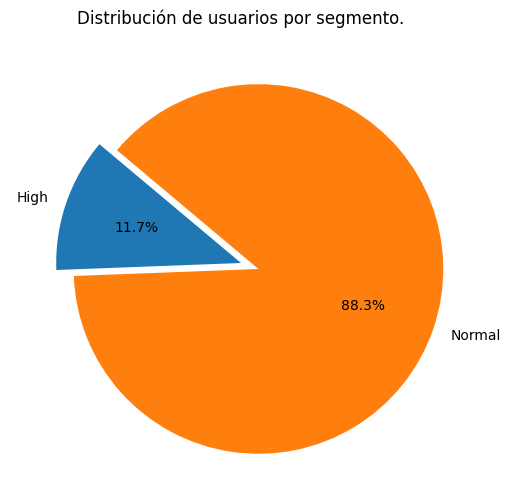

In [ ]:
plt.figure(figsize=(8, 6))
plt.pie(impacto_economico,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        explode=(0, 0.1))

plt.title('Distribución de usuarios por segmento.')
plt.show()

Se detectó que el 11.7% del volumen total de apuestas corresponde a perfiles de alto riesgo. Analizando las 100 transacciones, se encontró una alerta de posible lavado de dinero y se identificó 1 posible bot. Se recomienda a la brevedad aplicar auditoría a esas alertas.